<a href="https://colab.research.google.com/github/karolclemente/Lenguajedeprogramaci-n/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [6]:
import yfinance
activos = ["UPS","VLO","UNH"]

precios = yfinance.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker             UNH         UPS         VLO         UNH         UPS   
Date                                                                     
2024-01-02  508.214813  134.933273  121.295235  508.516295  136.791020   
2024-01-03  510.749573  134.251556  124.154472  515.234826  135.742862   
2024-01-04  513.943909  133.782852  120.970314  517.317324  134.916246   
2024-01-05  506.367828  135.257095  119.754204  515.432654  135.887709   
2024-01-08  505.557587  136.279694  120.004860  509.072311  136.339352   

Price                          Low                                Open  \
Ticker             VLO         UNH         UPS         VLO         UNH   
Date                                                                     
2024-01-02  122.464922  496.275955  133.194843  120.728955  496.436186   
2024-01-03  125.435554  508.346687  133.092599  121.165258  511.701238   
2024-01-04  125.992568  511.663582  133.288590  120.896046  513.548163   
2024-01-05  121.935778  502.928447  133.152224  118.890866  515.432654   
2024-01-08  120.134825  497.529255  134.200387  115.632433  508.271387   

Price                                Volume                    
Ticker             UPS         VLO      UNH      UPS      VLO  
Date                                                           
2024-01-02  133.740235  121.276664  3415700  4363800  2638200  
2024-01-03  134.021479  121.230233  2891400  3257200  3078000  
2024-01-04  133.833981  124.924997  2994400  3173400  2586500  
2024-01-05  133.297092  121.155973  2815400  2537300  2958000  
2024-01-08  135.129266  117.442675  2648900  2469500  2756500

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [9]:
# cierre = precios["Close"]


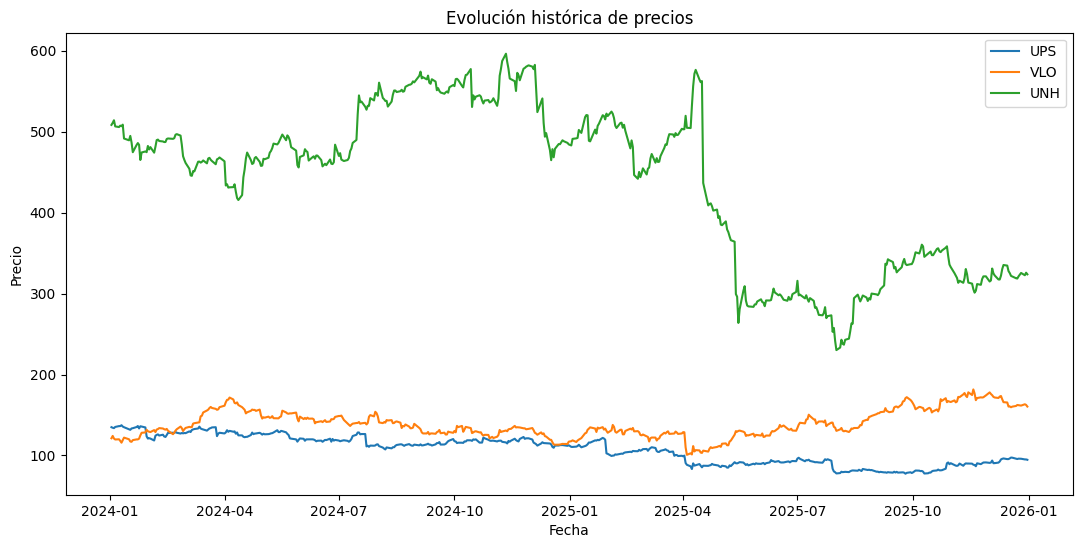

In [18]:
import matplotlib.pyplot as plt

# Extraemos los precios de cierre si no se ha hecho antes
cierre = precios["Close"]

fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()

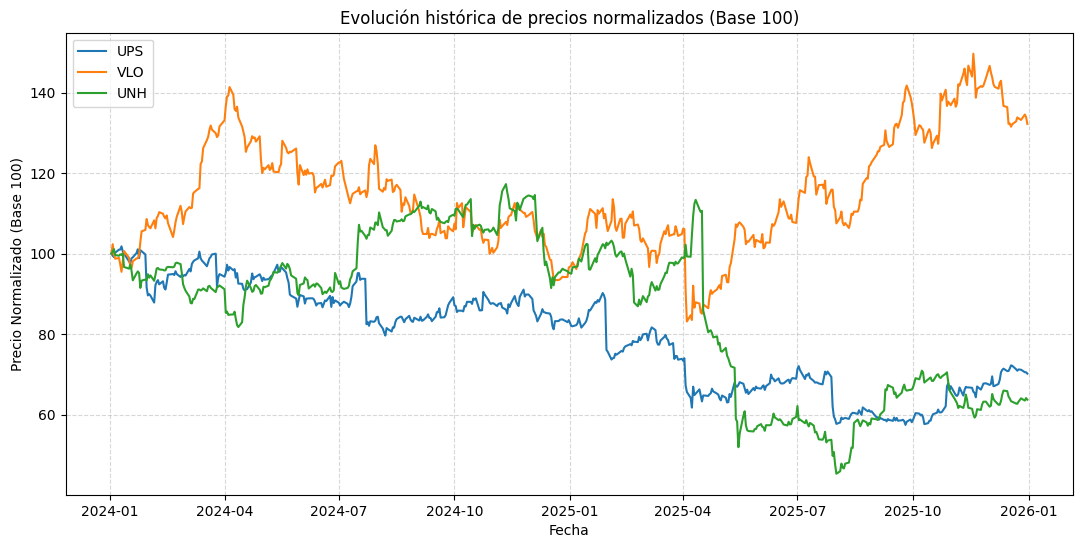

In [19]:
# 3. Normalizar y graficar en base 100
cierre_normalizado = (cierre / cierre.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre_normalizado.index, cierre_normalizado[activo], label=activo)

ax.set_title("Evolución histórica de precios normalizados (Base 100)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio Normalizado (Base 100)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

In [20]:
rendimientos = cierre.pct_change()

rendimientos.head()


Ticker,UNH,UPS,VLO
Date,,,
2024-01-02,NaN,NaN,NaN
2024-01-03,0.004988,-0.005052,0.023573
2024-01-04,0.006254,-0.003491,-0.025647
2024-01-05,-0.014741,0.011020,-0.010053
2024-01-08,-0.001600,0.007560,0.002093


In [22]:
rendimientos = rendimientos.dropna()

rendimientos.head()


Ticker,UNH,UPS,VLO
Date,,,
2024-01-03,0.004988,-0.005052,0.023573
2024-01-04,0.006254,-0.003491,-0.025647
2024-01-05,-0.014741,0.011020,-0.010053
2024-01-08,-0.001600,0.007560,0.002093
2024-01-09,0.003448,0.000125,-0.016245


El activo más volátil es: UNH con una desviación estándar diaria de 0.0243


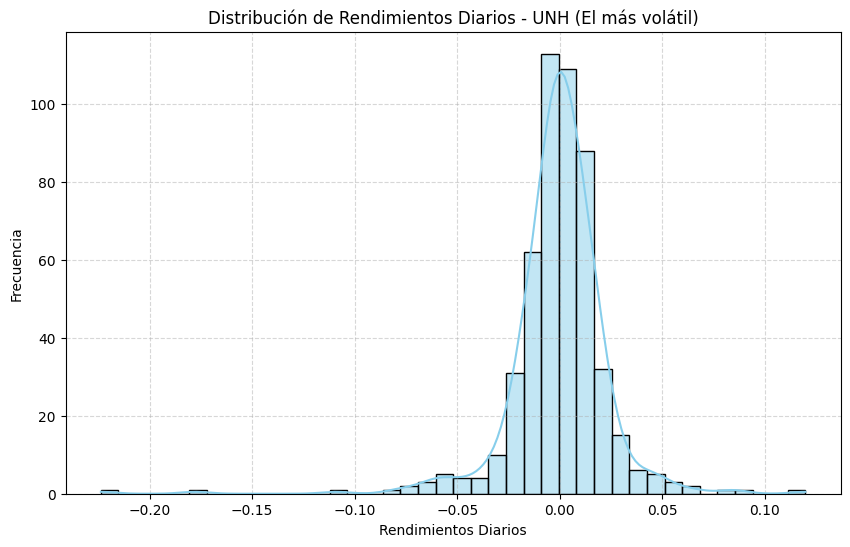

In [27]:
# 2. Histograma con el activo más volátil
# Calculamos la desviación estándar para identificar el más volátil
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()

print(f"El activo más volátil es: {activo_mas_volatil} con una desviación estándar diaria de {volatilidad[activo_mas_volatil]:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(rendimientos[activo_mas_volatil], kde=True, bins=40, color="skyblue")

plt.title(f"Distribución de Rendimientos Diarios - {activo_mas_volatil} (El más volátil)")
plt.xlabel("Rendimientos Diarios")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

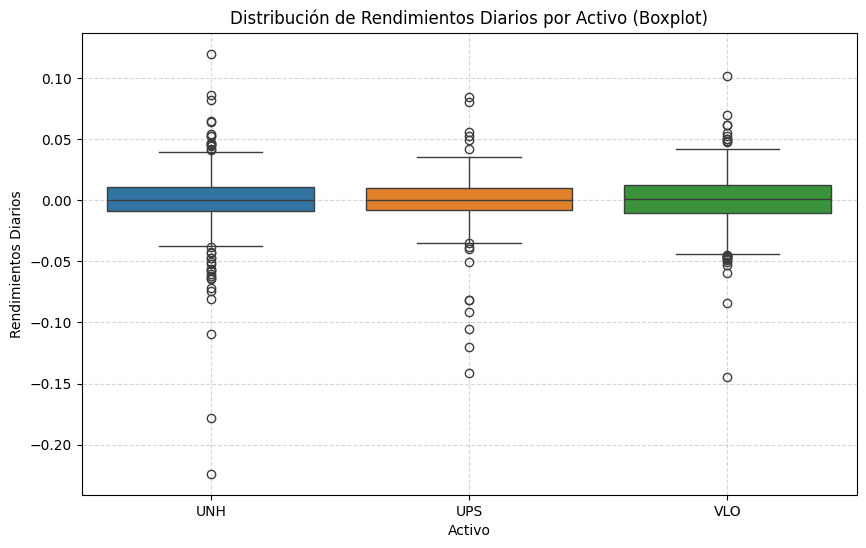

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos el Boxplot comparativo de rendimientos diarios
plt.figure(figsize=(10, 6))
sns.boxplot(data=rendimientos)

plt.title("Distribución de Rendimientos Diarios por Activo (Boxplot)")
plt.ylabel("Rendimientos Diarios")
plt.xlabel("Activo")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

In [28]:
correlacion = rendimientos.corr()

correlacion


Ticker,UNH,UPS,VLO
Ticker,,,
UNH,1.000000,0.118954,0.039719
UPS,0.118954,1.000000,0.279312
VLO,0.039719,0.279312,1.000000


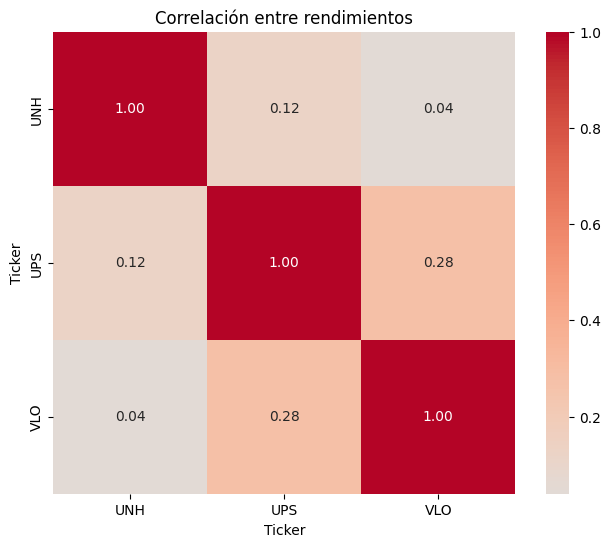

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()

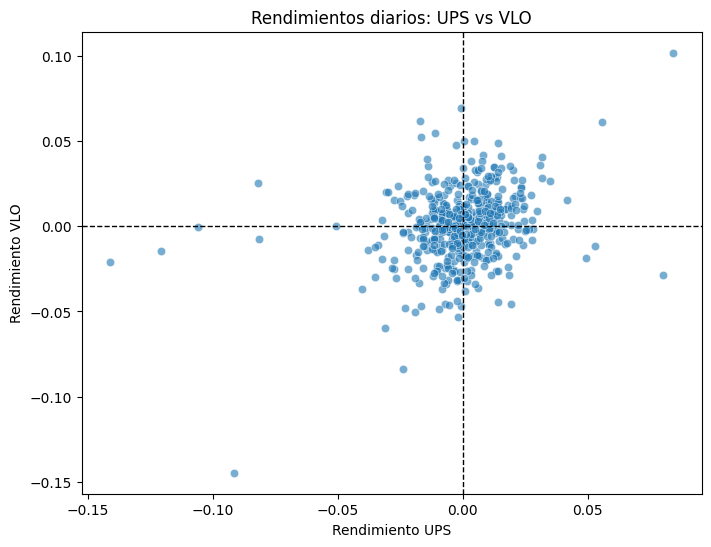

In [31]:
# 2. Dibujar un gráfico de dispersión utilizando Seaborn con activos existentes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="UPS",
    y="VLO",
    alpha=0.6
)

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.axvline(0, color="black", linewidth=1, linestyle="--")

plt.title("Rendimientos diarios: UPS vs VLO")
plt.xlabel("Rendimiento UPS")
plt.ylabel("Rendimiento VLO")

plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [33]:
import pandas as pd

# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
UNH,-0.000591,0.000348,0.024345,-0.223797,0.119784
UPS,-0.000526,0.000000,0.018767,-0.141127,0.084204
VLO,0.000782,0.001262,0.021073,-0.144664,0.101921
